In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('../data/caishen_bank_transactions.csv')

print(df.shape) # 11 columns, 6 million rows
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.info()

(6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [17]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [23]:
print("-- Check for Null Values:")
print(df.isnull().sum())

print("-- Check for duplicates:")
print(df.duplicated().sum())

-- Check for Null Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
-- Check for duplicates:
0


In [5]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [61]:
print(df['isFraud'].value_counts())

print("-- In percentage:")
print(df['isFraud'].value_counts(normalize=True)*100) 

# theres 8213 ACTUAL fraud or 0.13% (imbalance)


isFraud
0    6354407
1       8213
Name: count, dtype: int64
-- In percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


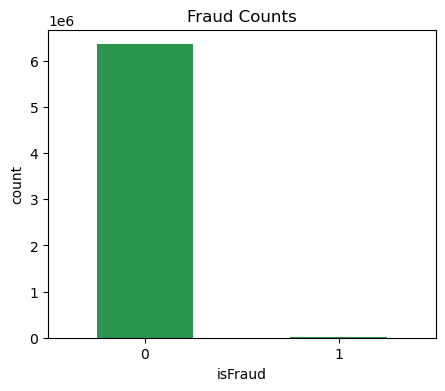

In [69]:
plt.figure(figsize=(5,4)) 
sns.barplot(df['isFraud'].value_counts(), width=0.5, color="#19A64A")
plt.title("Fraud Counts")
plt.show()

In [ ]:
# check which type of transactions had fraud
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

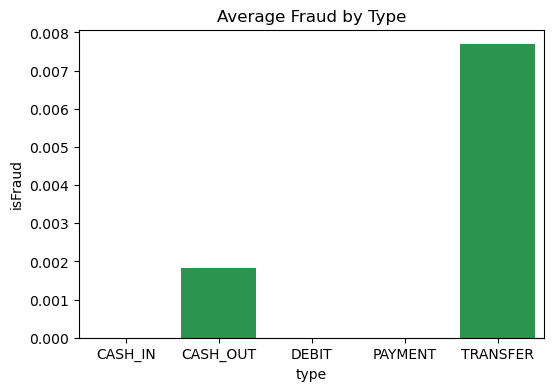

In [68]:
plt.figure(figsize=(6,4)) 
sns.barplot(df.groupby('type')['isFraud'].mean(), color="#19A64A")
plt.title("Average Fraud by Type")
plt.show()

Shows only type="CASH_OUT" and type="TRANSFER" are the only types of transactions where fraud shows up.

Check for:
1. which types of transactions does fraud show up
2. maybe find relationship which ones were flagged that were actually fraud?

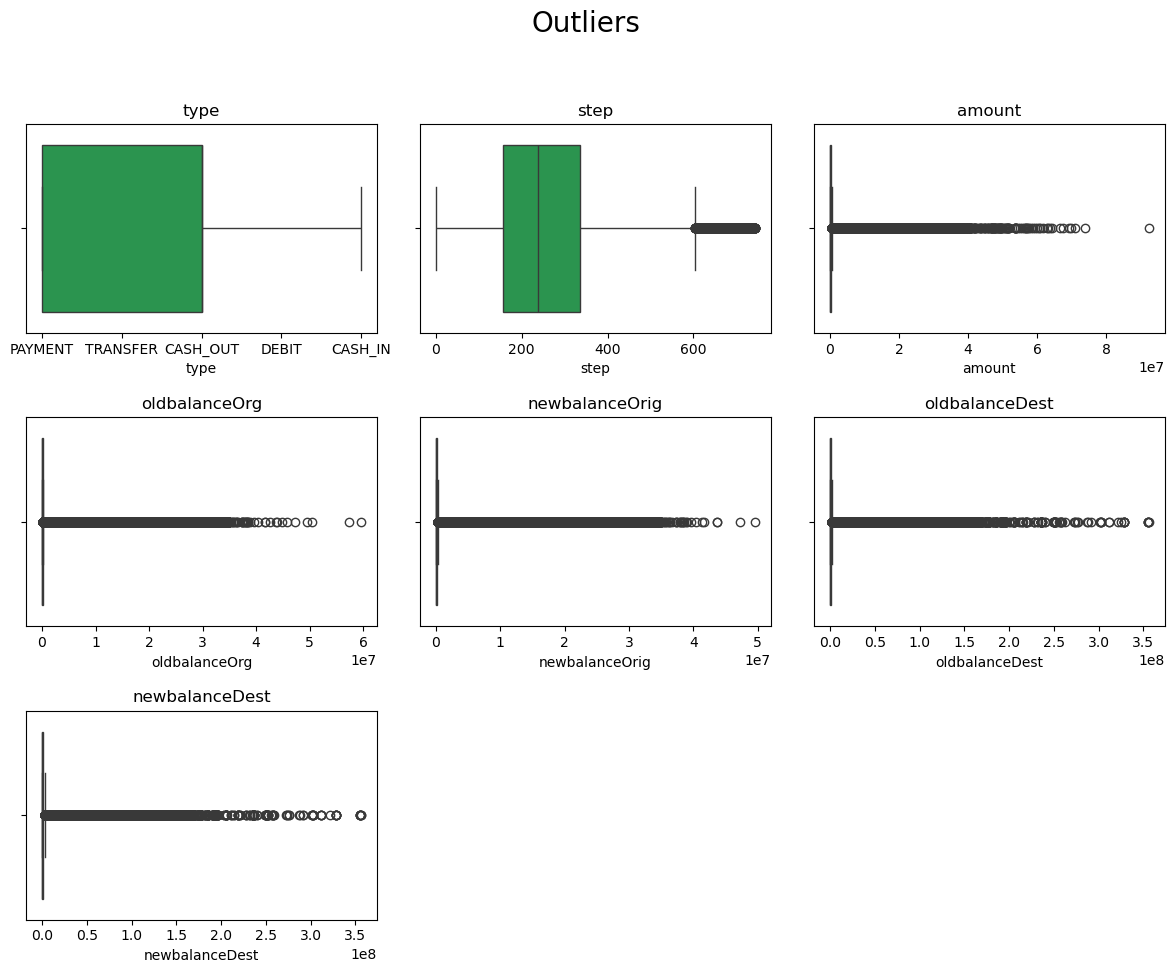

In [70]:
cols = ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'] #just testing -- change this!!!!!!

fig, ax = plt.subplots(4, 3, figsize=(12,12))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=ax[i], color="#19A64A")
    ax[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(ax)):
    ax[j].set_visible(False)

plt.suptitle('Outliers', y=1.02, fontsize=20)
plt.tight_layout(pad=1.5)
plt.show()

In [ ]:
df['log_amount'] = np.log1p(df["amount"]) #apply log to make 'amount' more balanced (The amount of money transferred)

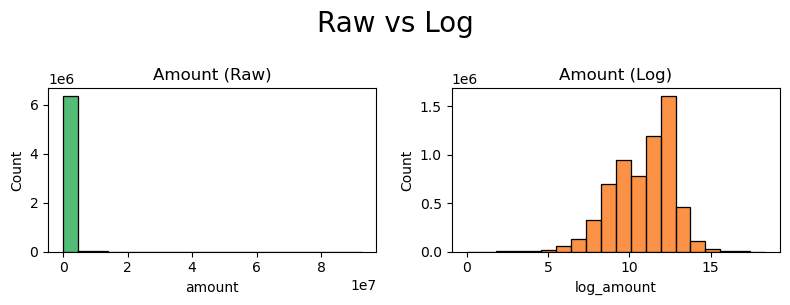

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))

sns.histplot(df['amount'], ax=ax[0], bins=20, color="#19A64A")
ax[0].set_title("Amount (Raw)")


sns.histplot(df['log_amount'], ax=ax[1], bins=20, color='#fa6e06')
ax[1].set_title("Amount (Log)")


plt.suptitle('Raw vs Log', y=1, fontsize=20)
plt.tight_layout()
plt.show()

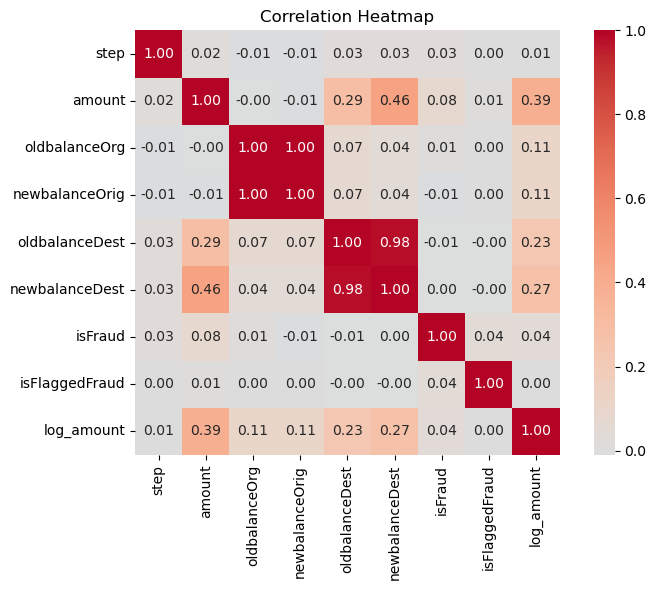

In [79]:
# Correlations of numerical features
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
